# MEC shank-reconstruction of task anchoring

For each **ENTm (MEC)** cell in an anchoring-switching session, xgboost predicts its spikes
from **each shank's MEC cells** (target excluded from its own shank). The cross-validated
predicted spikes are binned into a trial×position rate map and re-scored for anchoring with the
same `task_anchoring_catalogue` criteria — giving, per target, one predicted rate map + anchoring
raster **per shank**, plus **pR2** (overall, and split by the target's anchored / non-anchored epochs).

Plotted `plot_session`-style: leftmost column = the **observed** cell; the remaining columns = the
per-shank **predictions**. Run `run_shank_reconstruction.py` first to build the per-session cache.

In [1]:
import pickle, glob, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter

DATA_DIR = '/Users/harryclark/Documents/spatial-manifolds/data/xgboost_shank_anchoring'
OUT_DIR  = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/xgboost_shank_anchoring/figures'
os.makedirs(OUT_DIR, exist_ok=True)

CMAP_TA = ListedColormap(['#e7d7e8', '#9d5391', 'white'])
NORM_TA = BoundaryNorm([-0.5, 0.5, 1.5, 2], CMAP_TA.N)
SIGMA_TC = 2.5

print('cached sessions:')
for f in sorted(glob.glob(f'{DATA_DIR}/*_shank_reconstruction.pkl')):
    print('  ', os.path.basename(f))

cached sessions:
   M25D25_shank_reconstruction.pkl


In [2]:
def load_session(mouse, day):
    with open(f'{DATA_DIR}/M{mouse}D{day}_shank_reconstruction.pkl', 'rb') as f:
        return pickle.load(f)

def _tc_2d(tc_flat, n_trials, bpt):
    tc = gaussian_filter(np.nan_to_num(np.asarray(tc_flat)).astype(float), sigma=SIGMA_TC)
    n = min(len(tc) // bpt, n_trials)
    return tc[:n * bpt].reshape(n, bpt), n

def _rolling_hit(trial_type, trial_perf, n_trials, win=15):
    is_hit = (trial_perf == 'hit')
    k = np.ones(win) / win
    def roll(mask):
        num = np.convolve((mask & is_hit).astype(float), k, mode='same')
        den = np.convolve(mask.astype(float), k, mode='same')
        return np.where(den > 0, num / den * 100, np.nan)
    return roll(trial_type == 'b'), roll(trial_type == 'nb')

In [3]:
def plot_target(sess, target_id, save=False):
    tl, bs, bpt = sess['tl'], sess['bs'], sess['bpt']
    n_trials = sess['n_trials_ref']
    tinfo = sess['targets'][int(target_id)]
    t_shank = tinfo['shank']

    # build the column list: observed first, then one per shank (sorted)
    cols = [dict(kind='obs', title=f'observed\ncell {target_id}  sh{t_shank}',
                 tc=tinfo['observed_tc'], lab=tinfo['observed_labels'])]
    for sh in sorted(tinfo['shanks']):
        s = tinfo['shanks'][sh]
        star = '*' if s['is_same_shank'] else ''
        ne, npar = s.get('n_ent_used', s['n_cov_cells']), s.get('n_par_used', 0)
        title = (f'sh{sh}{star}  ({ne} ENT / {npar} PARA)\n'
                 f'pR2={s["pr2_overall"]:.2f}\n'
                 f'A={s["pr2_anchored"]:.2f}  N={s["pr2_nonanchored"]:.2f}')
        cols.append(dict(kind=f'sh{sh}', title=title, tc=s['pred_tc'], lab=s['pred_labels'],
                         color='#7a3f72'))
    N = len(cols)

    b_roll, nb_roll = _rolling_hit(sess['trial_type'], sess['trial_perf'], n_trials)
    trial_axis = np.arange(n_trials)
    y_top, y_bot = -0.5, n_trials - 0.5

    fig = plt.figure(figsize=(1.7 * N + 1.8, 4.2))
    gs = gridspec.GridSpec(2, N + 1, height_ratios=[1.1, 4.5],
                           width_ratios=[1] * N + [0.9],
                           hspace=0.06, wspace=0.18,
                           left=0.06, right=0.97, top=0.86, bottom=0.12)

    for ci, col in enumerate(cols):
        tc2d, n_use = _tc_2d(col['tc'], n_trials, bpt)
        lab = np.asarray(col['lab'], dtype=float) if col['lab'] is not None else np.full(n_use, np.nan)
        lab = lab[:n_use]
        pos = np.linspace(0, tl, bpt)
        anch, nonanch = np.where(lab == 1)[0], np.where(lab == 0)[0]
        m_anch    = np.nanmean(tc2d[anch], axis=0)    if len(anch)    else np.zeros(bpt)
        m_nonanch = np.nanmean(tc2d[nonanch], axis=0) if len(nonanch) else np.zeros(bpt)

        # avg FR shares the rate-map's position axis (nested to match the [1, 0.16]
        # split below), so it sits only above the rate map, not the anchoring raster
        sub_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, ci],
                                                   width_ratios=[1, 0.16], wspace=0.05)
        ax_avg = fig.add_subplot(sub_top[0])
        ax_avg.plot(pos, m_nonanch, color='#e7d7e8', lw=1.0)
        ax_avg.plot(pos, m_anch,    color='#9d5391', lw=1.0)
        ax_avg.set_xlim(0, tl); ax_avg.set_xticks([]); ax_avg.tick_params(labelsize=7)
        ax_avg.yaxis.set_major_locator(plt.MaxNLocator(3))
        for sp in ('top', 'right'): ax_avg.spines[sp].set_visible(False)
        ax_avg.set_title(col['title'], fontsize=7.5,
                         color=('#222' if col['kind'] == 'obs' else col.get('color', '#7a3f72')))
        if ci == 0: ax_avg.set_ylabel('FR (Hz)', fontsize=8)

        # rate map + anchoring raster strip
        sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1, ci],
                                               width_ratios=[1, 0.16], wspace=0.05)
        ax_rm = fig.add_subplot(sub[0]); ax_ra = fig.add_subplot(sub[1])
        vmax = float(np.nanpercentile(tc2d, 99)) or 1.0
        ax_rm.imshow(tc2d, aspect='auto', cmap='viridis', origin='upper',
                     extent=[0, tl, n_use - 0.5, -0.5], vmin=0, vmax=vmax, interpolation='nearest')
        ax_rm.set_xticks([0, tl // 2, tl]); ax_rm.set_xticklabels([0, tl // 2, tl], fontsize=7)
        ax_rm.set_xlabel('Pos (cm)', fontsize=8)
        for sp in ('top', 'right'): ax_rm.spines[sp].set_visible(False)
        if ci == 0:
            ax_rm.set_ylabel('Trial', fontsize=8)
        else:
            ax_rm.set_yticks([])

        strip = np.full((n_use, 1), np.nan); strip[:len(lab), 0] = lab
        ax_ra.imshow(np.where(np.isnan(strip), 2.0, strip), aspect='auto', cmap=CMAP_TA,
                     norm=NORM_TA, origin='upper', extent=[-0.5, 0.5, n_use - 0.5, -0.5],
                     interpolation='nearest')
        ax_ra.set_xticks([]); ax_ra.set_yticks([])
        for sp in ax_ra.spines.values(): sp.set_visible(False)

    ax_hit = fig.add_subplot(gs[1, N])
    ax_hit.plot(b_roll, trial_axis, color='#3bc500', lw=1.0, label='cued')
    ax_hit.plot(nb_roll, trial_axis, color='#333333', lw=1.0, label='uncued')
    ax_hit.set_xlim(0, 100); ax_hit.set_ylim(y_bot, y_top)
    ax_hit.set_xlabel('Hit %', fontsize=8); ax_hit.set_xticks([0, 50, 100])
    ax_hit.tick_params(labelsize=7); ax_hit.set_yticks([])
    for sp in ('top', 'right'): ax_hit.spines[sp].set_visible(False)
    ax_hit.legend(fontsize=6, loc='upper center', bbox_to_anchor=(0.5, 1.14),
                  frameon=False, ncol=2, columnspacing=1.0, handletextpad=0.4)

    fig.suptitle(f"M{sess['mouse']}D{sess['day']}  target {target_id} (shank {t_shank}) "
                 f"— observed vs per-shank MEC reconstruction", fontsize=9, y=0.98)
    if save:
        fig.savefig(f"{OUT_DIR}/M{sess['mouse']}D{sess['day']}_target{target_id}.pdf", bbox_inches='tight', dpi=200)
    return fig

M25D25: 65 targets, shanks [0, 1, 2, 3]


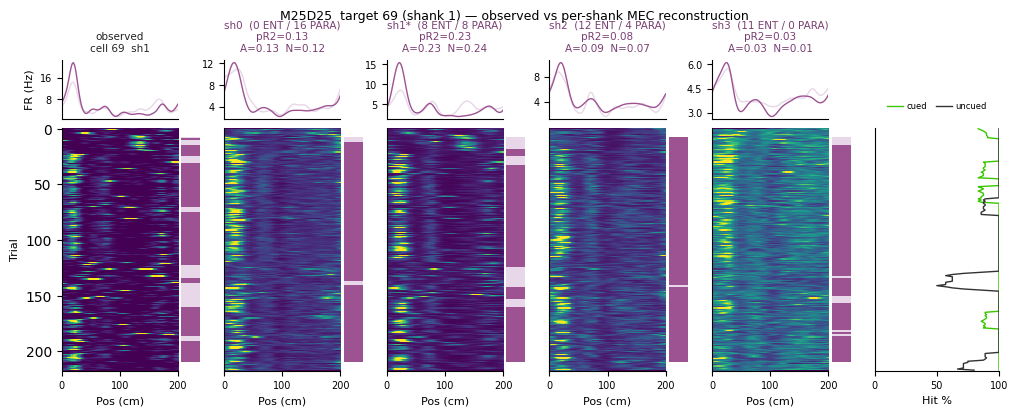

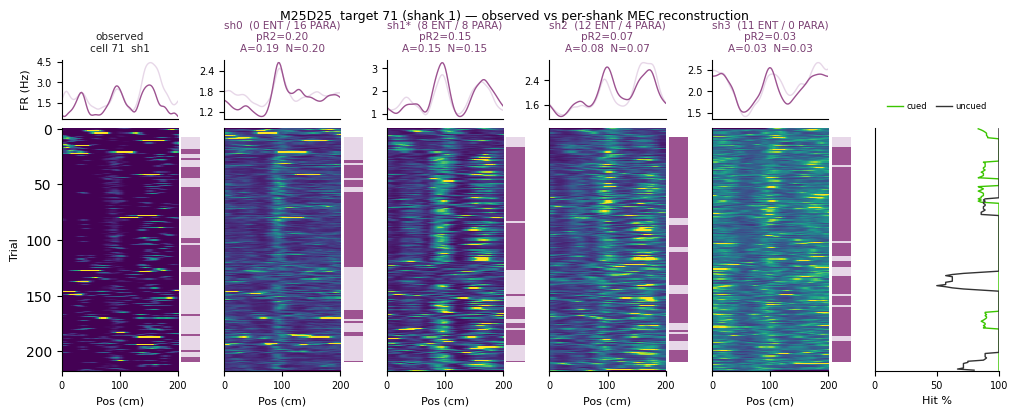

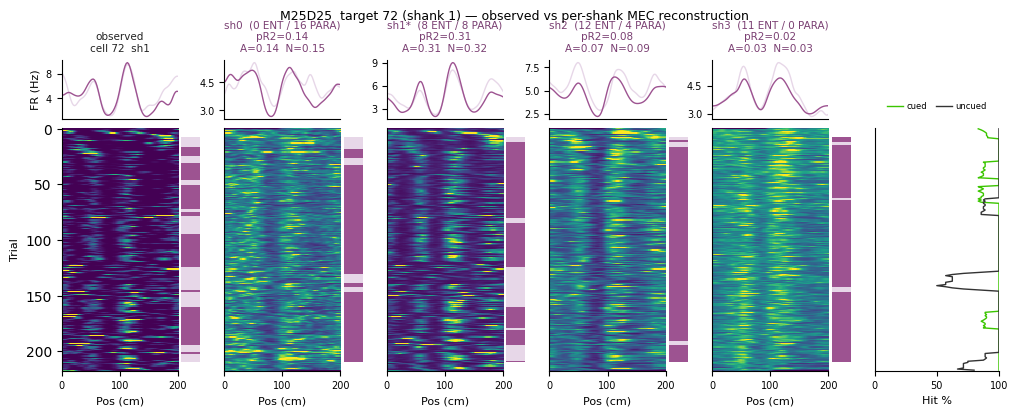

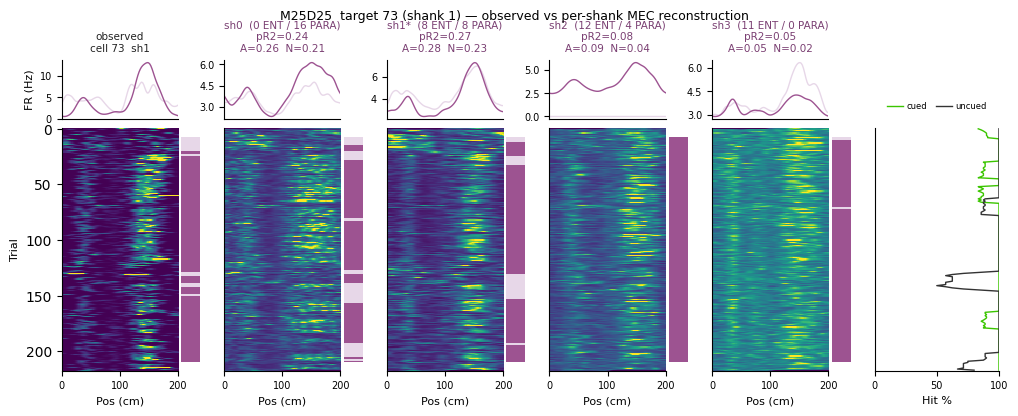

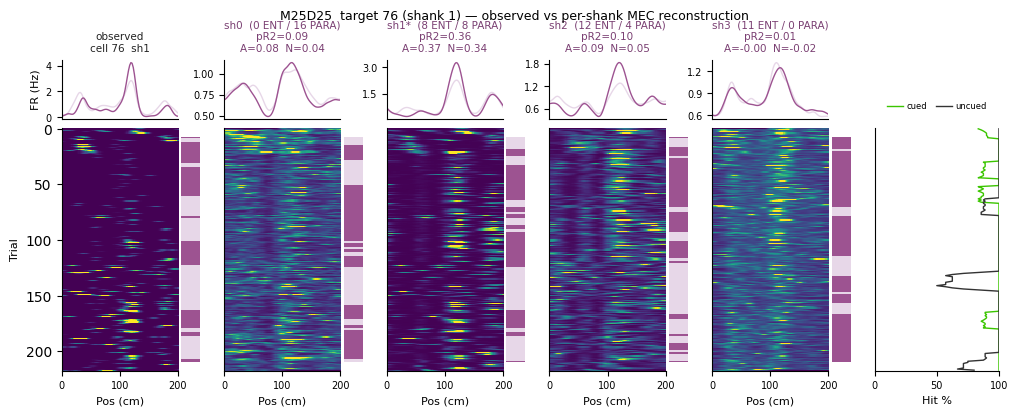

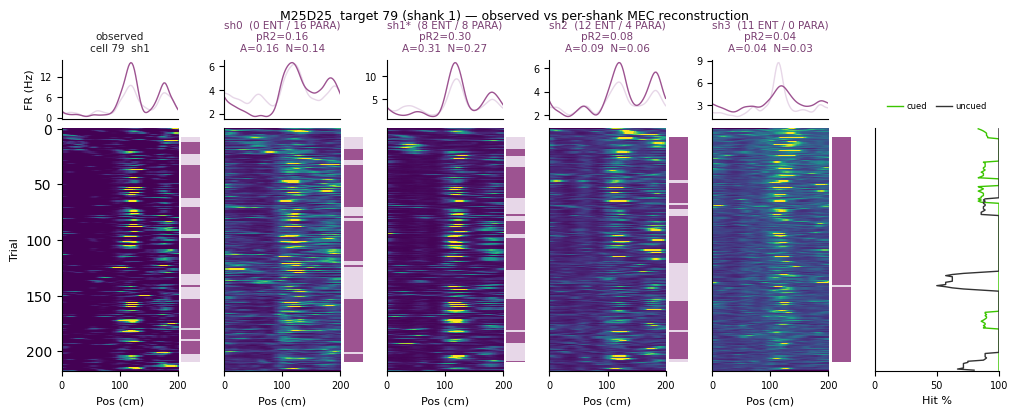

In [4]:
# ---- pick a session and plot every target (or a subset) ----
MOUSE, DAY = 25, 25
sess = load_session(MOUSE, DAY)
print(f"M{MOUSE}D{DAY}: {len(sess['targets'])} targets, shanks {sess['shanks_present']}")

for tid in list(sess['targets'])[:6]:      # first few; remove [:6] for all
    fig = plot_target(sess, tid, save=True)
    plt.show(); plt.close(fig)

In [5]:
# ---- pR2 summary table across all targets in this session ----
import pandas as pd
rows = []
for tid, ti in sess['targets'].items():
    for sh, s in ti['shanks'].items():
        rows.append(dict(target=tid, target_shank=ti['shank'], cov_shank=sh,
                         n_ent=s.get('n_ent_used', s['n_cov_cells']), n_par=s.get('n_par_used', 0),
                         same=s['is_same_shank'], n_cov=s['n_cov_cells'],
                         pR2=round(s['pr2_overall'], 3),
                         pR2_anch=round(s['pr2_anchored'], 3),
                         pR2_nonanch=round(s['pr2_nonanchored'], 3)))
pr2_df = pd.DataFrame(rows)
pr2_df.to_csv(f"{OUT_DIR}/M{MOUSE}D{DAY}_pR2_summary.csv", index=False)
print(pr2_df.head(20).to_string(index=False))

 target  target_shank  cov_shank  n_ent  n_par  same  n_cov   pR2  pR2_anch  pR2_nonanch
     69             1          0      0     16 False     16 0.128     0.135        0.121
     69             1          1      8      8  True     16 0.234     0.231        0.243
     69             1          2     12      4 False     16 0.083     0.087        0.071
     69             1          3     11      0 False     11 0.027     0.026        0.014
     71             1          0      0     16 False     16 0.199     0.187        0.204
     71             1          1      8      8  True     16 0.147     0.147        0.147
     71             1          2     12      4 False     16 0.072     0.083        0.066
     71             1          3     11      0 False     11 0.032     0.034        0.033
     72             1          0      0     16 False     16 0.142     0.144        0.145
     72             1          1      8      8  True     16 0.306     0.315        0.322
     72             1